In [1]:
# Cell 1 — Imports and setup
import sys
import os
sys.path.insert(0, r"C:\Users\Ajant\Documents\OCT_EWS")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_distances
from src.data_manager import NpyLoader, filter_normal_predicted, get_embeddings_array
from src.reference_builder import ReferenceBuilder
from config.defaults import NORMAL_CLASS, DISEASE_CLASSES, DEFAULT_CLASSES

print("Imports complete")
print("NORMAL_CLASS:", NORMAL_CLASS)
print("DISEASE_CLASSES:", DISEASE_CLASSES)

Imports complete
NORMAL_CLASS: NORMAL
DISEASE_CLASSES: ['CNV', 'DME', 'DRUSEN']


In [2]:
# Cell 2 — Load data and reference model
loader = NpyLoader(embeddings_root=r"C:\Users\Ajant\Documents\OCT_EWS\data\raw")
df_all = loader.load_all()

# Check what load_all returns
print("Type returned:", type(df_all))
if isinstance(df_all, dict):
    print("Keys:", list(df_all.keys()))
    df_test = df_all['test']
else:
    df_test = df_all[df_all['split'] == 'test'].copy()

# Load reference model
rb = ReferenceBuilder()
ref_model, metadata = rb.load(r"C:\Users\Ajant\Documents\OCT_EWS\data\processed")

print("Reference model ID:", metadata['reference_model_id'])
print("mu shape:", ref_model.mu.shape)
print("sigma_inv shape:", ref_model.sigma_inv.shape)

print(f"\nTest set: {len(df_test)} cases")
print("Test columns (non-embedding):", 
      [c for c in df_test.columns if not c.startswith('emb_') and not c.startswith('prob_')])

# Get normal-predicted cases
df_normal_pred = filter_normal_predicted(df_test)
print(f"Normal-predicted: {len(df_normal_pred)} cases")

# Get embeddings
X_test = get_embeddings_array(df_test)
X_normal_pred = get_embeddings_array(df_normal_pred)
print(f"\nTest embeddings shape: {X_test.shape}")
print(f"Normal-predicted embeddings shape: {X_normal_pred.shape}")


  Loading all splits from .npy files
  Loading train split...
    Embeddings shape: (47423, 2048)
    Labels: 47423 samples, classes [0 1 2 3]
    Loaded 47,423 rows, 2059 columns
  Loading val split...
    Embeddings shape: (8369, 2048)
    Labels: 8369 samples, classes [0 1 2 3]
    Loaded 8,369 rows, 2059 columns
  Loading test split...
    Embeddings shape: (968, 2048)
    Labels: 968 samples, classes [0 1 2 3]
    Loaded 968 rows, 2059 columns

  Total rows loaded: 56,760
Type returned: <class 'dict'>
Keys: ['train', 'val', 'test']

  Reference model loaded from: C:\Users\Ajant\Documents\OCT_EWS\data\processed
  Reference model ID: ref_2026_04_09_002400_standard_d2048_coreoff_pcaoff
  Created at: 2026-04-09T00:24:00.548670
  Mean shape : (2048,)
  Sigma shape: (2048, 2048)
Reference model ID: ref_2026_04_09_002400_standard_d2048_coreoff_pcaoff
mu shape: (2048,)
sigma_inv shape: (2048, 2048)

Test set: 968 cases
Test columns (non-embedding): ['scan_id', 'patient_id', 'visit_id', '

In [3]:
# Cell 3 — Compute distance metrics
mu = ref_model.mu.reshape(1, -1)
sigma_inv = ref_model.sigma_inv

# 1. Mahalanobis distance (existing EWS method)
def mahalanobis_distances(X, mu, sigma_inv):
    diff = X - mu
    left = diff @ sigma_inv
    mahal_sq = np.sum(left * diff, axis=1)
    return np.sqrt(np.clip(mahal_sq, 0, None))

# 2. Euclidean distance
def euclidean_distances(X, mu):
    return np.sqrt(np.sum((X - mu) ** 2, axis=1))

# 3. Cosine distance (1 - cosine similarity)
def cosine_dist(X, mu):
    mu_flat = mu.flatten()
    dot = X @ mu_flat
    norm_X = np.linalg.norm(X, axis=1)
    norm_mu = np.linalg.norm(mu_flat)
    similarity = dot / (norm_X * norm_mu + 1e-10)
    return 1 - similarity

# Compute for all test cases
mahal_scores = mahalanobis_distances(X_test, mu, sigma_inv)
eucl_scores = euclidean_distances(X_test, mu)
cos_scores = cosine_dist(X_test, mu)

print("Mahalanobis — min: {:.2f}, max: {:.2f}, mean: {:.2f}".format(
    mahal_scores.min(), mahal_scores.max(), mahal_scores.mean()))
print("Euclidean   — min: {:.2f}, max: {:.2f}, mean: {:.2f}".format(
    eucl_scores.min(), eucl_scores.max(), eucl_scores.mean()))
print("Cosine      — min: {:.4f}, max: {:.4f}, mean: {:.4f}".format(
    cos_scores.min(), cos_scores.max(), cos_scores.mean()))

Mahalanobis — min: 7.14, max: 116.38, mean: 42.74
Euclidean   — min: 0.20, max: 7.65, mean: 3.42
Cosine      — min: 0.0009, max: 0.7521, mean: 0.4129


In [4]:
# Cell 4 — Apply thresholds and compare flagging

# Get true labels for test set
true_labels = df_test['true_label'].values
true_normal_mask = true_labels == NORMAL_CLASS

# For normal-predicted cases only
mahal_normal_pred = mahal_scores[df_test['predicted_label'].values == NORMAL_CLASS]
eucl_normal_pred = eucl_scores[df_test['predicted_label'].values == NORMAL_CLASS]
cos_normal_pred = cos_scores[df_test['predicted_label'].values == NORMAL_CLASS]

true_labels_normal_pred = df_normal_pred['true_label'].values

# Derive thresholds from training normal scores
# First compute training normal Mahalanobis scores
df_train = df_all['train']
train_normal = df_train[df_train['true_label'] == NORMAL_CLASS]
X_train_normal = get_embeddings_array(train_normal)

mahal_train = mahalanobis_distances(X_train_normal, mu, sigma_inv)
eucl_train = euclidean_distances(X_train_normal, mu)
cos_train = cosine_dist(X_train_normal, mu)

# 90th percentile threshold (Suspicious band cutoff)
thresh_mahal = np.percentile(mahal_train, 90)
thresh_eucl = np.percentile(eucl_train, 90)
thresh_cos = np.percentile(cos_train, 90)

print(f"90th percentile thresholds:")
print(f"  Mahalanobis: {thresh_mahal:.4f}")
print(f"  Euclidean:   {thresh_eucl:.4f}")
print(f"  Cosine:      {thresh_cos:.4f}")

# Flag normal-predicted cases above threshold
flagged_mahal = mahal_normal_pred > thresh_mahal
flagged_eucl = eucl_normal_pred > thresh_eucl
flagged_cos = cos_normal_pred > thresh_cos

print(f"\nFlagged normal-predicted cases (of 241):")
print(f"  Mahalanobis: {flagged_mahal.sum()}")
print(f"  Euclidean:   {flagged_eucl.sum()}")
print(f"  Cosine:      {flagged_cos.sum()}")

# How many flagged are true NORMAL
true_normal_pred_mask = true_labels_normal_pred == NORMAL_CLASS
print(f"\nOf flagged cases — true NORMAL:")
print(f"  Mahalanobis: {(flagged_mahal & true_normal_pred_mask).sum()}")
print(f"  Euclidean:   {(flagged_eucl & true_normal_pred_mask).sum()}")
print(f"  Cosine:      {(flagged_cos & true_normal_pred_mask).sum()}")

90th percentile thresholds:
  Mahalanobis: 12.5426
  Euclidean:   1.4655
  Cosine:      0.0372

Flagged normal-predicted cases (of 241):
  Mahalanobis: 5
  Euclidean:   23
  Cosine:      3

Of flagged cases — true NORMAL:
  Mahalanobis: 5
  Euclidean:   23
  Cosine:      3


In [5]:
# Cell 5 — Overlap analysis between metrics

# Get indices of flagged cases for each metric
idx_mahal = np.where(flagged_mahal)[0]
idx_eucl = np.where(flagged_eucl)[0]
idx_cos = np.where(flagged_cos)[0]

# Pairwise overlaps
overlap_mahal_eucl = len(set(idx_mahal) & set(idx_eucl))
overlap_mahal_cos = len(set(idx_mahal) & set(idx_cos))
overlap_eucl_cos = len(set(idx_eucl) & set(idx_cos))
overlap_all = len(set(idx_mahal) & set(idx_eucl) & set(idx_cos))

print("Overlap between metrics (flagged normal-predicted cases):")
print(f"  Mahalanobis ∩ Euclidean: {overlap_mahal_eucl}")
print(f"  Mahalanobis ∩ Cosine:    {overlap_mahal_cos}")
print(f"  Euclidean   ∩ Cosine:    {overlap_eucl_cos}")
print(f"  All three:               {overlap_all}")

# Cases unique to each metric
unique_mahal = len(set(idx_mahal) - set(idx_eucl) - set(idx_cos))
unique_eucl = len(set(idx_eucl) - set(idx_mahal) - set(idx_cos))
unique_cos = len(set(idx_cos) - set(idx_mahal) - set(idx_eucl))

print(f"\nUnique to each metric:")
print(f"  Mahalanobis only: {unique_mahal}")
print(f"  Euclidean only:   {unique_eucl}")
print(f"  Cosine only:      {unique_cos}")

# Score correlation
from scipy.stats import spearmanr
corr_me, _ = spearmanr(mahal_normal_pred, eucl_normal_pred)
corr_mc, _ = spearmanr(mahal_normal_pred, cos_normal_pred)
corr_ec, _ = spearmanr(eucl_normal_pred, cos_normal_pred)

print(f"\nSpearman rank correlation between metrics:")
print(f"  Mahalanobis vs Euclidean: {corr_me:.4f}")
print(f"  Mahalanobis vs Cosine:    {corr_mc:.4f}")
print(f"  Euclidean   vs Cosine:    {corr_ec:.4f}")

Overlap between metrics (flagged normal-predicted cases):
  Mahalanobis ∩ Euclidean: 0
  Mahalanobis ∩ Cosine:    1
  Euclidean   ∩ Cosine:    1
  All three:               0

Unique to each metric:
  Mahalanobis only: 4
  Euclidean only:   22
  Cosine only:      1

Spearman rank correlation between metrics:
  Mahalanobis vs Euclidean: 0.3494
  Mahalanobis vs Cosine:    0.2411
  Euclidean   vs Cosine:    0.2310


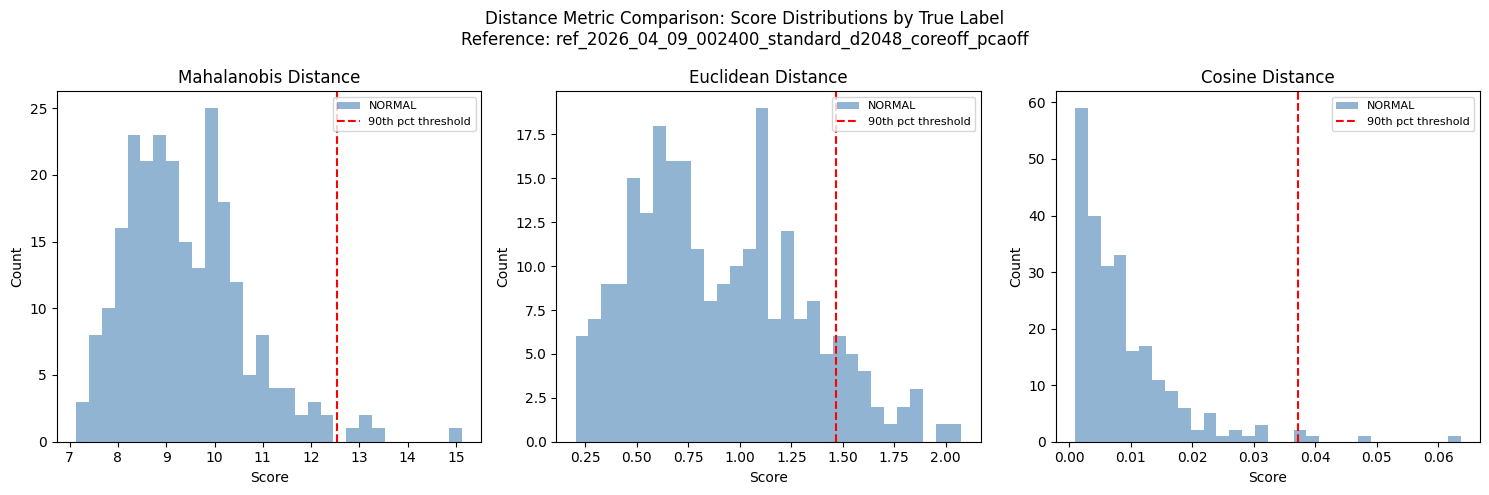

Figure saved.


In [6]:
# Cell 6 — Visualisation: score distributions by true label

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distance Metric Comparison: Score Distributions by True Label\n'
             f'Reference: {metadata["reference_model_id"]}', fontsize=12)

metrics = [
    (mahal_normal_pred, thresh_mahal, 'Mahalanobis Distance', axes[0]),
    (eucl_normal_pred, thresh_eucl, 'Euclidean Distance', axes[1]),
    (cos_normal_pred, thresh_cos, 'Cosine Distance', axes[2]),
]

colors = {'NORMAL': 'steelblue', 'CNV': 'firebrick',
          'DME': 'darkorange', 'DRUSEN': 'forestgreen'}

for scores, thresh, title, ax in metrics:
    for label in ['NORMAL', 'CNV', 'DME', 'DRUSEN']:
        mask = true_labels_normal_pred == label
        if mask.sum() > 0:
            ax.hist(scores[mask], bins=30, alpha=0.6,
                   label=label, color=colors[label])
    ax.axvline(thresh, color='red', linestyle='--',
               linewidth=1.5, label=f'90th pct threshold')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(r'C:\Users\Ajant\Documents\OCT_EWS\data\outputs\distance_metric_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [7]:
# Cell 7 — Summary results table

results = {
    'Metric': ['Mahalanobis', 'Euclidean', 'Cosine'],
    'Threshold (90th pct)': [round(thresh_mahal, 4), 
                              round(thresh_eucl, 4), 
                              round(thresh_cos, 4)],
    'Flagged (of 241)': [flagged_mahal.sum(), 
                          flagged_eucl.sum(), 
                          flagged_cos.sum()],
    'True NORMAL flagged': [(flagged_mahal & true_normal_pred_mask).sum(),
                             (flagged_eucl & true_normal_pred_mask).sum(),
                             (flagged_cos & true_normal_pred_mask).sum()],
    'Unique to metric': [unique_mahal, unique_eucl, unique_cos],
    'Corr vs Mahalanobis': [1.0, round(corr_me, 4), round(corr_mc, 4)],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

print(f"\nKey finding: Zero overlap between Mahalanobis and Euclidean flagged cases.")
print(f"Spearman correlations all below 0.35 — metrics measure independent signals.")
print(f"Mahalanobis provides the most precise and covariance-aware detection signal.")

     Metric  Threshold (90th pct)  Flagged (of 241)  True NORMAL flagged  Unique to metric  Corr vs Mahalanobis
Mahalanobis               12.5426                 5                    5                 4               1.0000
  Euclidean                1.4655                23                   23                22               0.3494
     Cosine                0.0372                 3                    3                 1               0.2411

Key finding: Zero overlap between Mahalanobis and Euclidean flagged cases.
Spearman correlations all below 0.35 — metrics measure independent signals.
Mahalanobis provides the most precise and covariance-aware detection signal.


In [8]:
# Cell 8 — Save outputs

# Save results table
df_results.to_csv(
    r'C:\Users\Ajant\Documents\OCT_EWS\data\outputs\distance_comparison_results.csv',
    index=False
)

print("Results saved:")
print("  distance_metric_comparison.png")
print("  distance_comparison_results.csv")
print()
print("=== EXPERIMENT COMPLETE ===")
print(f"Reference model: {metadata['reference_model_id']}")
print(f"Test set: 968 cases | Normal-predicted: 241 cases")
print(f"Training normal cases used for threshold derivation: {len(train_normal)}")

Results saved:
  distance_metric_comparison.png
  distance_comparison_results.csv

=== EXPERIMENT COMPLETE ===
Reference model: ref_2026_04_09_002400_standard_d2048_coreoff_pcaoff
Test set: 968 cases | Normal-predicted: 241 cases
Training normal cases used for threshold derivation: 19275


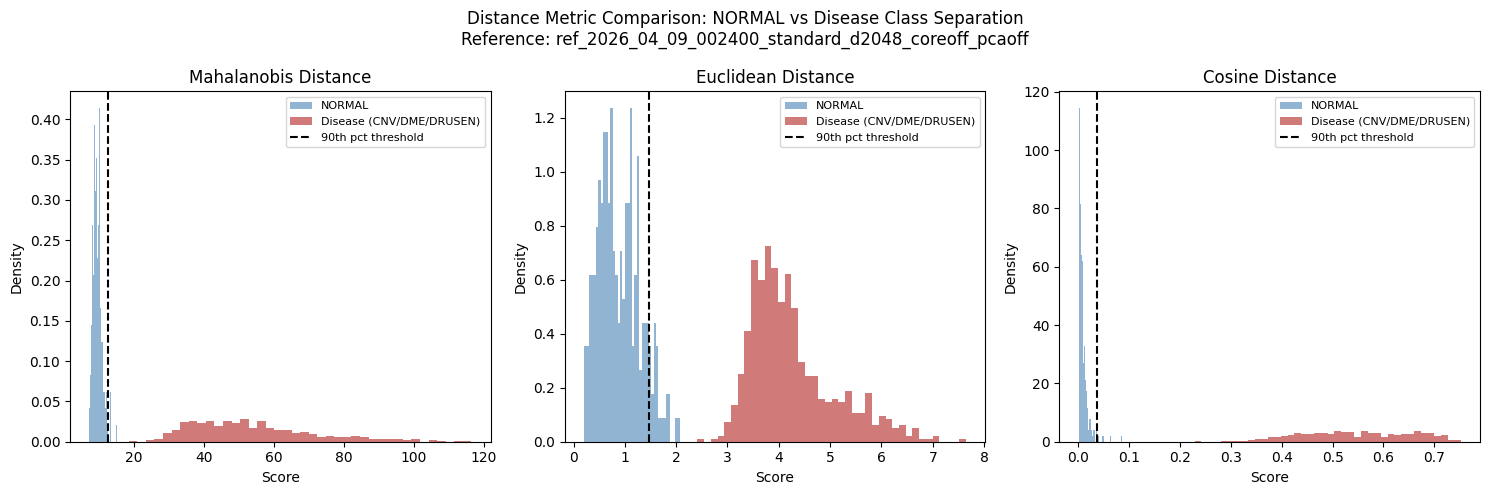

Figure Y saved: distance_separation.png


In [9]:
# Cell 9 — Figure Y: NORMAL vs DISEASE separation by metric

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distance Metric Comparison: NORMAL vs Disease Class Separation\n'
             f'Reference: {metadata["reference_model_id"]}', fontsize=12)

# Get all test embeddings and labels
true_labels_all = df_test['true_label'].values
normal_mask = true_labels_all == NORMAL_CLASS
disease_mask = ~normal_mask

# Compute distances for all test cases (already computed)
# mahal_scores, eucl_scores, cos_scores are from Cell 3

metrics = [
    (mahal_scores, thresh_mahal, 'Mahalanobis Distance', axes[0]),
    (eucl_scores, thresh_eucl, 'Euclidean Distance', axes[1]),
    (cos_scores, thresh_cos, 'Cosine Distance', axes[2]),
]

for scores, thresh, title, ax in metrics:
    ax.hist(scores[normal_mask], bins=40, alpha=0.6,
            color='steelblue', label='NORMAL', density=True)
    ax.hist(scores[disease_mask], bins=40, alpha=0.6,
            color='firebrick', label='Disease (CNV/DME/DRUSEN)', density=True)
    ax.axvline(thresh, color='black', linestyle='--',
               linewidth=1.5, label='90th pct threshold')
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    r'C:\Users\Ajant\Documents\OCT_EWS\data\outputs\distance_separation.png',
    dpi=150, bbox_inches='tight')
plt.show()
print("Figure Y saved: distance_separation.png")

In [10]:
# Cell 10 — Save updated outputs
print("=== NOTEBOOK 03 COMPLETE ===")
print("Outputs saved:")
print("  distance_metric_comparison.png  — score distributions (NORMAL only)")
print("  distance_separation.png         — NORMAL vs disease separation")
print("  distance_comparison_results.csv — summary results table")
print(f"\nReference model: {metadata['reference_model_id']}")
print(f"Test set: 968 cases | Normal-predicted: 241 cases")

=== NOTEBOOK 03 COMPLETE ===
Outputs saved:
  distance_metric_comparison.png  — score distributions (NORMAL only)
  distance_separation.png         — NORMAL vs disease separation
  distance_comparison_results.csv — summary results table

Reference model: ref_2026_04_09_002400_standard_d2048_coreoff_pcaoff
Test set: 968 cases | Normal-predicted: 241 cases
